In [132]:
import os


import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC, predictive
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
from pyro.infer.autoguide import init_to_value

# qutip model
import numpy as np
import matplotlib.pyplot as plt
import helper
import odmrsimulator
from func import mcmc




In [133]:
temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

temps = temps + 273.15  # Convert to Kelvin

temps = torch.tensor(temps).double()



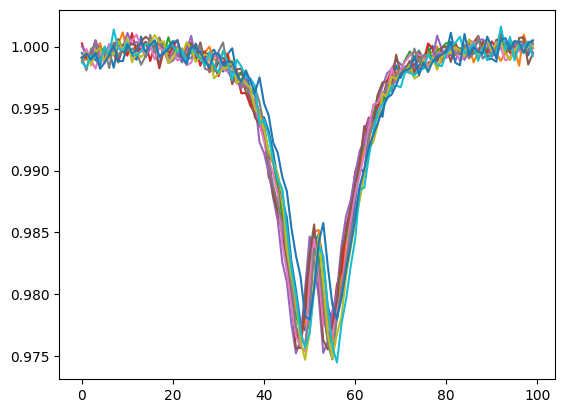

In [134]:
## import data file
fpath = '../saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

torch.set_default_dtype(torch.float64)


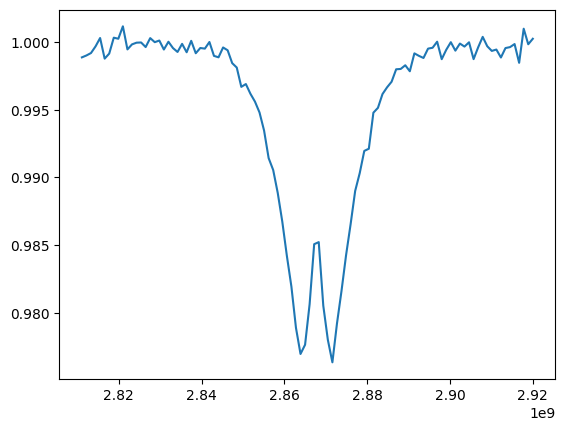

In [135]:
x_obs, y_obs = x_esr, y_esr.iloc[:, 1]  
data_ = (temps[1], (x_obs, y_obs))

plt.plot(x_obs, y_obs)

## Set up and run Bayesian inference

In [161]:

odmrsimulator.D0 = 2877
odmrsimulator.T0 = 300.
odmrsimulator.alpha = -0.072
# odmrsimulator.T1_0 = T1_0
# odmrsimulator.beta = beta
# odmrsimulator.T2_0 = T2_0
# odmrsimulator.gamma = gamma
# odmrsimulator.D_MHz = D_MHz
# odmrsimulator.D_rad_s = D_rad_s
# odmrsimulator.gamma_nv = gamma_nv
odmrsimulator.B = 0.0
# If you want to enable strain, set E_rad_s in the module; otherwise keep None
odmrsimulator.E_rad_s = 3.14* 4 * 5e6
# odmrsimulator.strain_angle = strain_angle


RF_sweep = np.linspace(2820, 2950, 200)  # increase RF resolution slightly for smoother curves
PL = np.zeros(len(RF_sweep))

for i, RF_freq in enumerate(RF_sweep):
    PL[ i] = odmrsimulator.NV_ODMR(0.0, RF_freq, .5, 300)


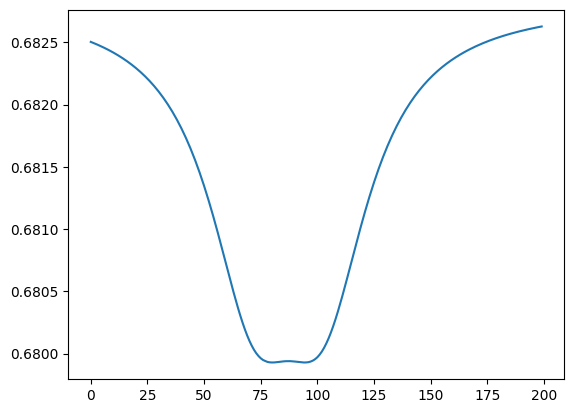

In [162]:
plt.plot(PL*100)

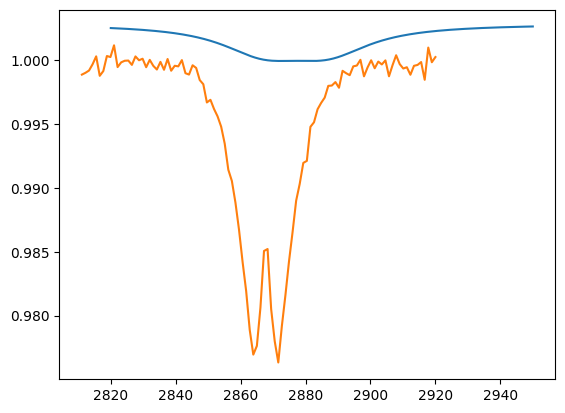

In [163]:
plt.plot(RF_sweep, (((PL*100))+0.32)/1.  ); #plt.show()
plt.plot(x_obs/1e6, y_obs)

In [138]:
# # solve for the posterior using MCMC
# # Use the observed x positions and y values as the data passed to the model
# # bind the `odmrsimulator` argument with a module-level function so multiprocessing can pickle it
posterior = mcmc(model_module.model, odmrsimulator, data_, num_samples=200, warmup_steps=2000,
         num_chains=1, jit_compile=True, max_tree_depth=3)


NameError: name 'model_module' is not defined

In [ ]:


# robustly convert posterior samples to numpy whether they are torch tensors or numpy arrays
raw = posterior.get_samples()
hmc_samples = {}
for k, v in raw.items():
    if isinstance(v, torch.Tensor):
        hmc_samples[k] = v.detach().cpu().numpy()
    else:
        hmc_samples[k] = np.asarray(v)
alpha = hmc_samples['alpha']

# T = T_ * np.ones_like(alpha)  # Create T array matching alpha shape
# F = F_np(x_scale, Amp, alpha, beta, T)
# qs = mquantiles(F.T, [0.025, 0.975], axis=0)
# F_mean = F.mean(axis = 1)


plt.figure(figsize = (10, 35)) # Increased figure size to accommodate new subplots
plt.subplot(7,1,1)
plt.hist(alpha, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of alpha", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for alpha');
plt.xlabel("Alpha value");


In [ ]:
print(f'alpha = {np.array(alpha).mean():.4f}')
print(f'alpha error = {np.array(alpha).var():.6f}')

print(f'gamma = {np.array(hmc_samples["gamma"]).mean():.4f}')
print(f'gamma error = {np.array(hmc_samples["gamma"]).var():.6f}')


## Get results and plot

In [ ]:
# idx = []
# error_alpha = []
# error_beta = []
# alpha_, beta_, amp_ = [], [], []
# gamma1_vals = []
# beta_var, alpha_var, gamma1_var, amp_var = [], [], [], []

# # init vals for MCMC

# init_vals = {
#     "alpha": torch.tensor(-0.077),
#     "beta": torch.tensor(71.0),
#     "gamma1": torch.tensor(7.8),
#     "amp": torch.tensor(3.0),
#     "var": torch.tensor(0.05),}


# for j in range(0, df.shape[1]-2):
#   print(j)
#   print(init_vals)
#   x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
#   temps_j = temps[j]
#   data_j_ = (temps_j, (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double()))
#   kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
#   posterior = MCMC(kernel, num_samples=2000, warmup_steps=200, num_chains=1)
#   posterior.run(data_j_)
#   hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
#   alpha = hmc_samples['alpha']
#   beta = hmc_samples['beta']
#   Amp = hmc_samples['amp'] # Get posterior samples for amp
#   var = hmc_samples['var'] # Get posterior samples for var
#   T = temps_j.item() * np.ones_like(alpha)  # Create T array matching alpha shape
#   gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
#   gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
#   var = hmc_samples['var'] # Get posterior samples for var
#   F = F_np(x_scale, Amp, alpha, beta, T)
#   qs = mquantiles(F.T, [0.025, 0.975], axis=0)
#   F_mean = F.mean(axis = 1)
#   idx.append(j)
#   amp_.append(Amp.mean())  
#   alpha_.append(alpha.mean())
#   beta_.append(beta.mean())
#   gamma1_vals.append(gamma1_.mean())
#   alpha_var.append(alpha.var())
#   beta_var.append(beta.var())
#   gamma1_var.append(gamma1_.var())
#   amp_var.append(Amp.var())
#   print('#################')
#   plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
#   plt.plot(x_scale, F_mean)
#   plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
#   plt.xlabel('frequency axis')
#   plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
#   #pyro.clear_param_store()
#   init_vals = {
#       "alpha": torch.tensor(alpha.mean()),
#       "beta": torch.tensor(beta.mean()),
#       "gamma1": torch.tensor(gamma1_.mean()),
#       "amp": torch.tensor(Amp.mean()),
#       "var": torch.tensor(var.mean()),}    
#   print('#################')


df.shape[1]

In [ ]:
# print(f'alpha = {np.array(alpha_).mean():.4f}')
# print(f'alpha error = {np.array(alpha_var).mean():.6f}')

# print(f'alpha = {np.array(beta_).mean():.4f}')
# print(f'alpha error = {np.array(beta_var).mean():.6f}')